## TITLE:VISUALIZATITON OF CONSULTATION PATTERNS USING CHANNEL-WISE DASHBOARDS AND RESOLUTION TIME DISTRIBUTIONS

## Import Libries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots

## Data Loading

In [2]:
df = pd.read_csv(r"telemedicine_consultation_dataset.csv")
df

,Patient_ID,Appointment_Date,Age,Gender,Heart_Disease,Diabetes,Respiratory_Disease,Skin_Disease,Fever_Infection,Consultancy_Fee
0,P100000,11-09-2023,67,Male,No,Yes,No,No,No,368
1,P100001,07-03-2024,46,Female,No,No,Yes,No,No,332
2,P100002,23-09-2023,34,Female,No,Yes,No,No,Yes,520
3,P100003,20-11-2023,65,Male,No,No,No,Yes,Yes,550
4,P100004,02-05-2024,47,Male,No,No,Yes,Yes,No,515
...,...,...,...,...,...,...,...,...,...,...
79995,P179995,06-11-2023,39,Female,No,No,Yes,Yes,No,431
79996,P179996,07-04-2024,52,Female,No,No,No,No,No,206
79997,P179997,19-06-2024,37,Female,No,No,No,No,No,296
79998,P179998,20-01-2023,68,Female,No,Yes,Yes,No,Yes,623


In [3]:
df.shape[1]

10

In [4]:
df.shape[0]

80000

In [5]:
df.size

800000

In [6]:
df.tail()

,Patient_ID,Appointment_Date,Age,Gender,Heart_Disease,Diabetes,Respiratory_Disease,Skin_Disease,Fever_Infection,Consultancy_Fee
79995,P179995,06-11-2023,39,Female,No,No,Yes,Yes,No,431
79996,P179996,07-04-2024,52,Female,No,No,No,No,No,206
79997,P179997,19-06-2024,37,Female,No,No,No,No,No,296
79998,P179998,20-01-2023,68,Female,No,Yes,Yes,No,Yes,623
79999,P179999,28-09-2023,73,Male,Yes,Yes,Yes,No,No,622


In [7]:
df.head()

,Patient_ID,Appointment_Date,Age,Gender,Heart_Disease,Diabetes,Respiratory_Disease,Skin_Disease,Fever_Infection,Consultancy_Fee
0,P100000,11-09-2023,67,Male,No,Yes,No,No,No,368
1,P100001,07-03-2024,46,Female,No,No,Yes,No,No,332
2,P100002,23-09-2023,34,Female,No,Yes,No,No,Yes,520
3,P100003,20-11-2023,65,Male,No,No,No,Yes,Yes,550
4,P100004,02-05-2024,47,Male,No,No,Yes,Yes,No,515


In [8]:
df.keys()

Index(['Patient_ID', 'Appointment_Date', 'Age', 'Gender', 'Heart_Disease',
       'Diabetes', 'Respiratory_Disease', 'Skin_Disease', 'Fever_Infection',
       'Consultancy_Fee'],
      dtype='object')

In [9]:
df.iloc[45]

Patient_ID                P100045
Appointment_Date       05-05-2022
Age                            45
Gender                       Male
Heart_Disease                  No
Diabetes                      Yes
Respiratory_Disease            No
Skin_Disease                  Yes
Fever_Infection                No
Consultancy_Fee               452
Name: 45, dtype: object

In [10]:
df.loc[51]

Patient_ID                P100051
Appointment_Date       13-08-2023
Age                            66
Gender                       Male
Heart_Disease                 Yes
Diabetes                       No
Respiratory_Disease           Yes
Skin_Disease                   No
Fever_Infection               Yes
Consultancy_Fee               584
Name: 51, dtype: object

In [11]:
df.describe

<bound method NDFrame.describe of       Patient_ID Appointment_Date  Age  Gender Heart_Disease Diabetes  \
0        P100000       11-09-2023   67    Male            No      Yes   
1        P100001       07-03-2024   46  Female            No       No   
2        P100002       23-09-2023   34  Female            No      Yes   
3        P100003       20-11-2023   65    Male            No       No   
4        P100004       02-05-2024   47    Male            No       No   
...          ...              ...  ...     ...           ...      ...   
79995    P179995       06-11-2023   39  Female            No       No   
79996    P179996       07-04-2024   52  Female            No       No   
79997    P179997       19-06-2024   37  Female            No       No   
79998    P179998       20-01-2023   68  Female            No      Yes   
79999    P179999       28-09-2023   73    Male           Yes      Yes   

      Respiratory_Disease Skin_Disease Fever_Infection  Consultancy_Fee  
0              

In [12]:
df.isnull().sum()

Patient_ID             0
Appointment_Date       0
Age                    0
Gender                 0
Heart_Disease          0
Diabetes               0
Respiratory_Disease    0
Skin_Disease           0
Fever_Infection        0
Consultancy_Fee        0
dtype: int64

In [13]:
df.duplicated().sum()

0

 ## DESCRIPTION:shows how many patients with heart disease used telemedicine consultations

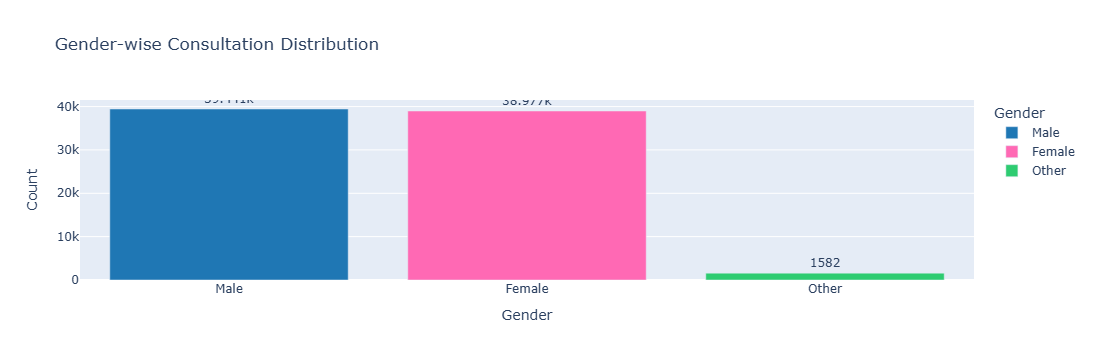

In [14]:
fig = px.bar(df, x = 'Heart_Disease', y = 'Patient_ID', title = 'Heart Disease Consultation Distrubtion'),
gender_counts = df["Gender"].value_counts().reset_index()
gender_counts.columns = ["Gender", "Count"]

fig = px.bar(
    gender_counts,
    x="Gender",
    y="Count",
    color="Gender",
    title="Gender-wise Consultation Distribution",
    text_auto=True,
    color_discrete_map={
        "Male": "#1f77b4",
        "Female": "#ff69b4",
        "Other": "#2ecc71"
    }
)

fig.update_traces(textposition="outside")

fig.show()


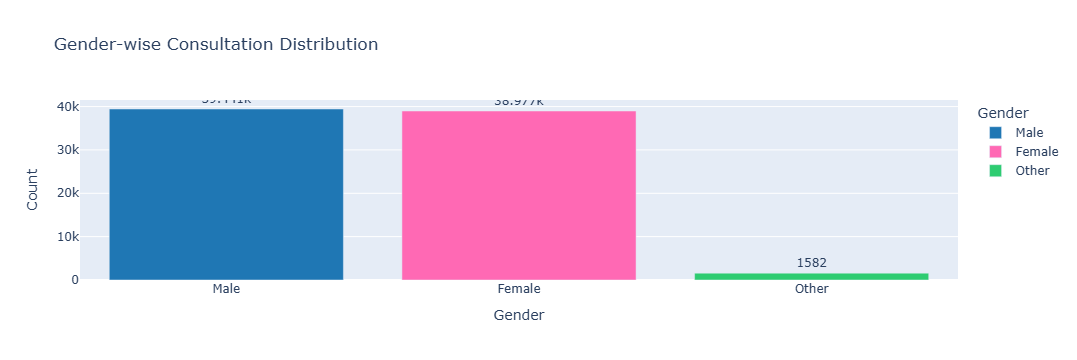

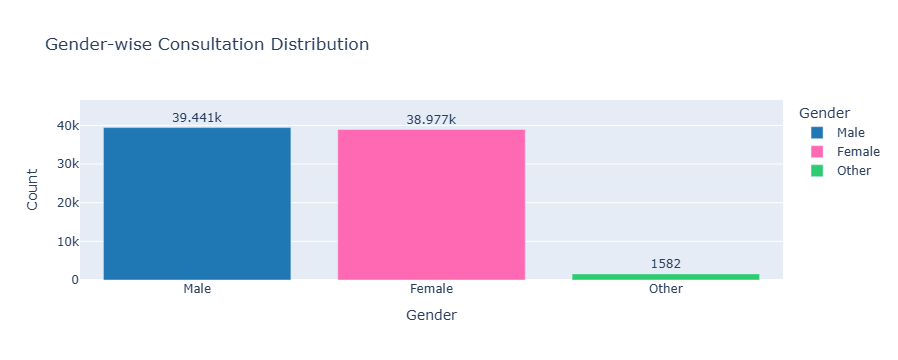

In [15]:
fig = px.bar(df, x = 'Diabetes', y = 'Patient_ID', title = 'Diabetes Consultation Distrubtion'),
import plotly.express as px

gender_counts = df["Gender"].value_counts().reset_index()
gender_counts.columns = ["Gender", "Count"]

fig = px.bar(
    gender_counts,
    x="Gender",
    y="Count",
    color="Gender",
    title="Gender-wise Consultation Distribution",
    text_auto=True,
    color_discrete_map={
        "Male": "#1f77b4",
        "Female": "#ff69b4",
        "Other": "#2ecc71"
    }
)

fig.update_traces(textposition="outside")

fig.show()
fig.show()

## DESCRIPTION:Displays how telemedicine consultations are distributed across different genders. It helps analyze demographic usage of telemedicine services.

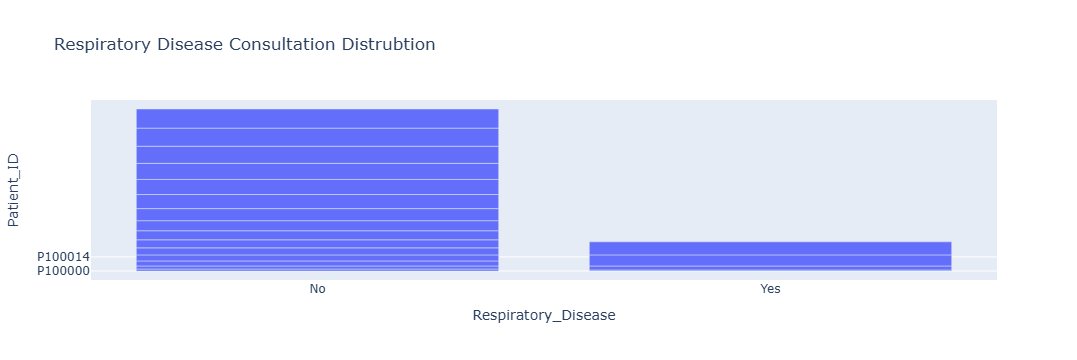

In [16]:
fig = px.bar(df.head(20), x = 'Respiratory_Disease', y = 'Patient_ID', title = 'Respiratory Disease Consultation Distrubtion')
fig.show()

In [ ]:
## TITLE: RESPIRATORY DISEASE

In [ ]:
 ## DESCRIPTION:Shows the frequency of respiratory disease cases handled through telemedicine consultations.


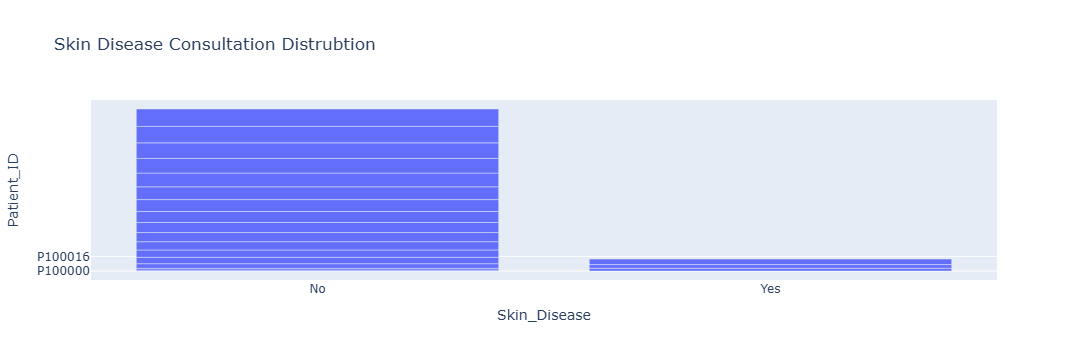

In [17]:
fig = px.bar(df.head(20), x = 'Skin_Disease', y = 'Patient_ID', title = 'Skin Disease Consultation Distrubtion')
fig.show()

In [ ]:
## TITLE:SKIN DISEASE

In [ ]:
## DESCRIPTION:displays the number of telemedicine consultations for dermatological conditions

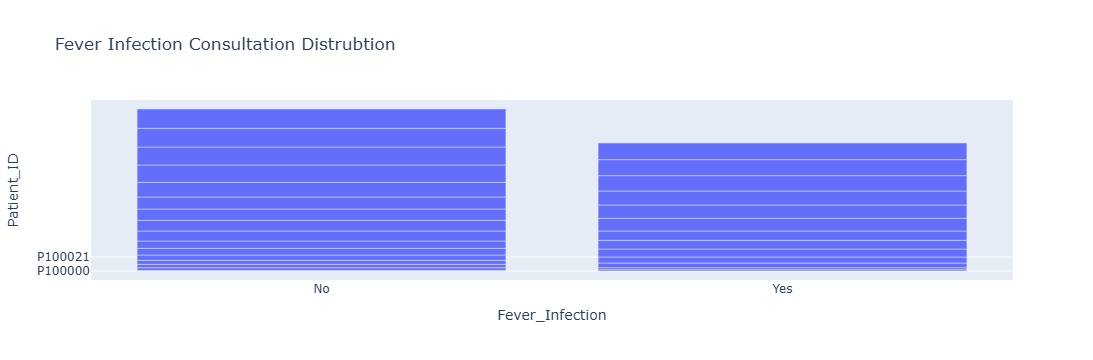

In [18]:
fig = px.bar(df.head(30), x = 'Fever_Infection', y = 'Patient_ID', title = 'Fever Infection Consultation Distrubtion')
fig.show()

In [ ]:
## TITLE:FEVER INFECTION

In [ ]:
## DESCRIPTION:Shows how often patients consult telemedicine services for fever or infection symptoms


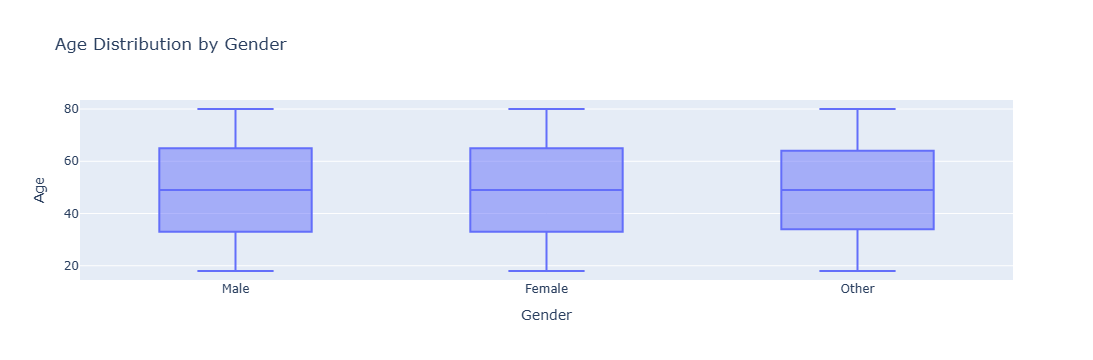

In [19]:
fig = px.box(df, x = 'Gender', y = 'Age', title = "Age Distribution by Gender")
fig.show()

In [ ]:
## TITLE:AGE DISTRIBUTION BY GENDER

In [ ]:
## DESCRIPTION:Compares age distribution between male and female telemedicine patients.

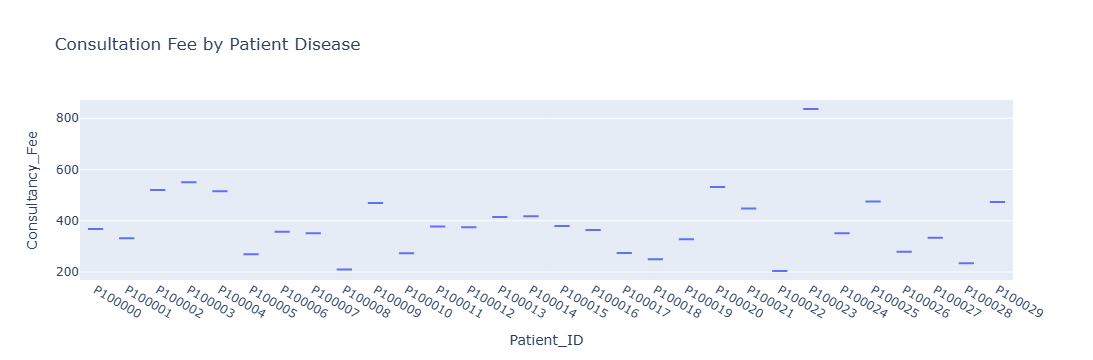

In [20]:
fig = px.box(df.head(30), x = 'Patient_ID', y = 'Consultancy_Fee', title = "Consultation Fee by Patient Disease")
fig.show()

In [ ]:
## TITLE:CONSULTATION FEE BY PATIENT DISEASE

In [ ]:
## DESCRIPTION:Shows how consultancy fees vary across different disease conditions.


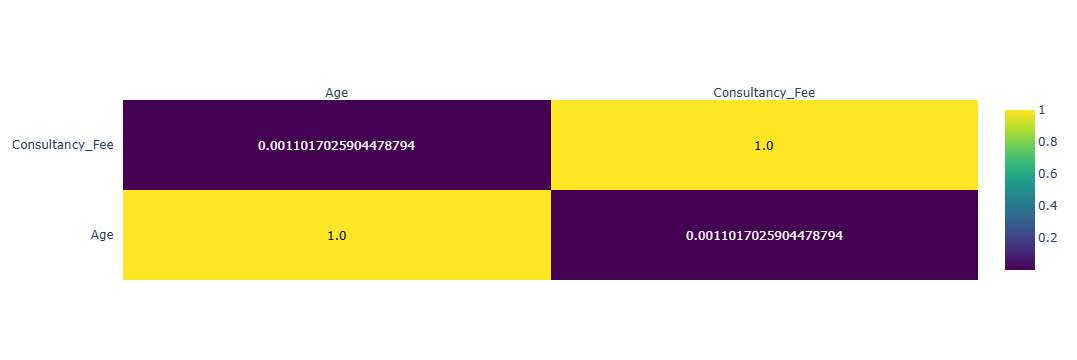

In [21]:
numeric_df=df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
fig = ff.create_annotated_heatmap(
    z = corr_matrix.values,
    x = list(corr_matrix.columns),
    y = list(corr_matrix.index),
    colorscale = 'Viridis',
    showscale = True
)
fig.show()

In [ ]:
## DESCRIPTION:Shows the relationship between patient age and consultation fees, helping analyze whether consultation cost varies with age.


## 3D Consultation Pattern Plot

In [ ]:
DESCRIPTION:Shows the relationship between patient age and consultation fees, helping analyze whether consultation cost varies with age.


## Animation 1 — Consultation Trends by Date

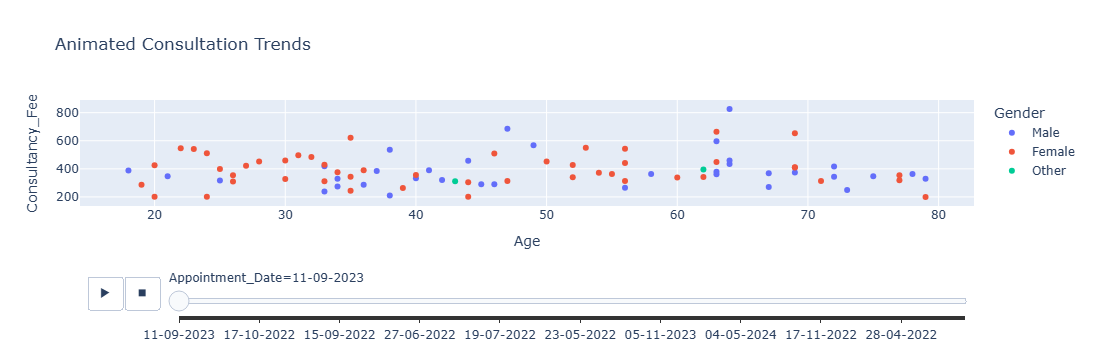

In [23]:
fig = px.scatter(df,
                 x="Age",
                 y="Consultancy_Fee",
                 color="Gender",
                 animation_frame="Appointment_Date",
                 title="Animated Consultation Trends")

fig.show()

In [ ]:
## DESCRIPTION:Displays the number of consultations occurring each month to identify seasonal patterns in telemedicine usage.

## Animation 2 — Disease Consultation Evolution

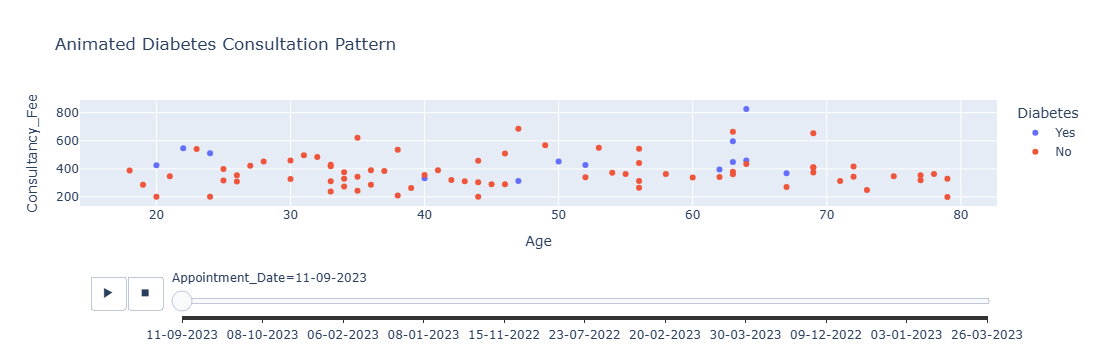

In [24]:
fig = px.scatter(df,
                 x="Age",
                 y="Consultancy_Fee",
                 color="Diabetes",
                 animation_frame="Appointment_Date",
                 title="Animated Diabetes Consultation Pattern")

fig.show()

In [ ]:
## DESCRIPTION:Displays the number of telemedicine consultations involving diabetes patients.

## Main Dashboard

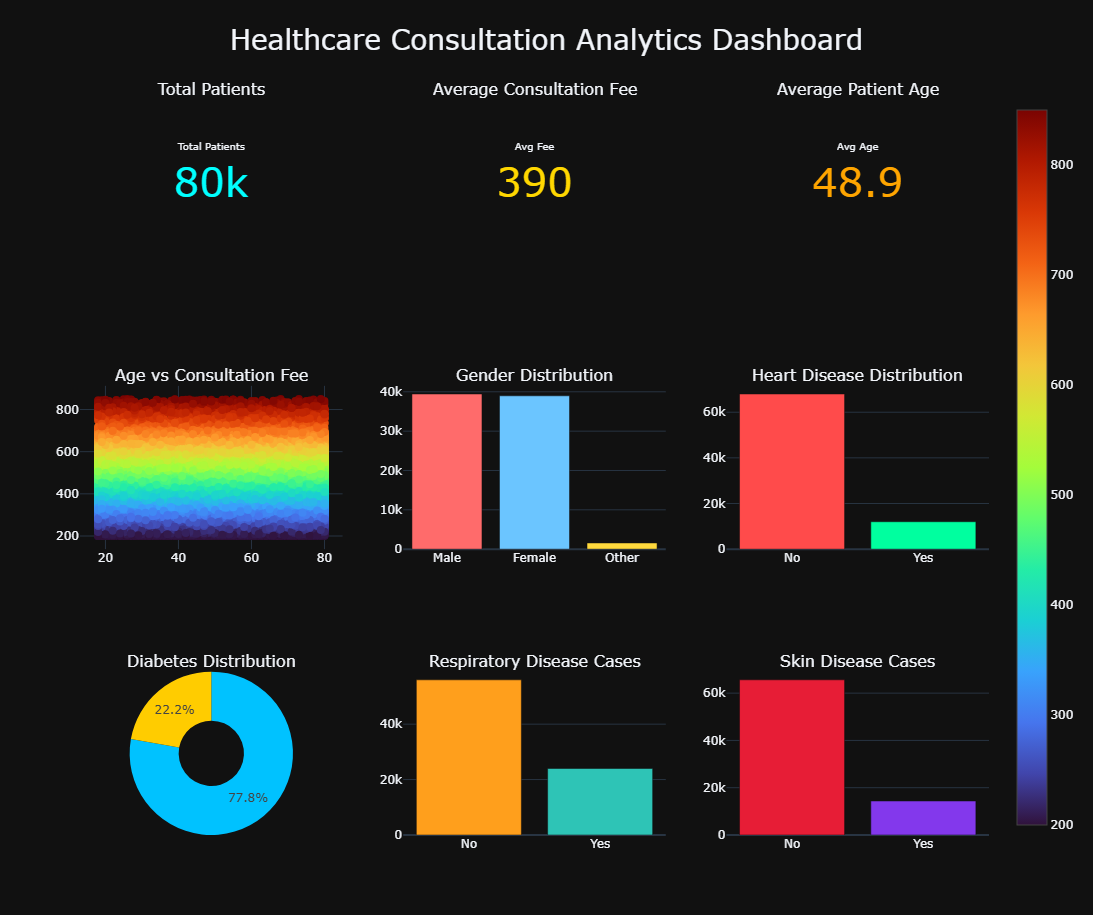

In [25]:
total_patients = df["Patient_ID"].count()
avg_fee = df["Consultancy_Fee"].mean()
avg_age = df["Age"].mean()

fig = make_subplots(
    rows=3, cols=3,
    specs=[
        [{"type":"indicator"}, {"type":"indicator"}, {"type":"indicator"}],
        [{"type":"xy"}, {"type":"xy"}, {"type":"xy"}],
        [{"type":"domain"}, {"type":"xy"}, {"type":"xy"}]
    ],
    subplot_titles=(
        "Total Patients",
        "Average Consultation Fee",
        "Average Patient Age",
        "Age vs Consultation Fee",
        "Gender Distribution",
        "Heart Disease Distribution",
        "Diabetes Distribution",
        "Respiratory Disease Cases",
        "Skin Disease Cases"
    )
)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_patients,
    title={"text":"Total Patients"},
    number={"font":{"color":"cyan","size":40}}
), row=1, col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=avg_fee,
    title={"text":"Avg Fee"},
    number={"font":{"color":"gold","size":40}}
), row=1, col=2)

fig.add_trace(go.Indicator(
    mode="number",
    value=avg_age,
    title={"text":"Avg Age"},
    number={"font":{"color":"orange","size":40}}
), row=1, col=3)

fig.add_trace(go.Scatter(
    x=df["Age"],
    y=df["Consultancy_Fee"],
    mode="markers",
    marker=dict(
        size=8,
        color=df["Consultancy_Fee"],
        colorscale="Turbo",
        showscale=True
    ),
    name="Age vs Fee"
), row=2, col=1)

gender_counts = df["Gender"].value_counts()

fig.add_trace(go.Bar(
    x=gender_counts.index,
    y=gender_counts.values,
    marker_color=["#ff6b6b","#6bc5ff","#ffd93d"],
    name="Gender"
), row=2, col=2)

heart_counts = df["Heart_Disease"].value_counts()

fig.add_trace(go.Bar(
    x=heart_counts.index,
    y=heart_counts.values,
    marker_color=["#ff4b4b","#00ff9f"],
    name="Heart Disease"
), row=2, col=3)

diabetes_counts = df["Diabetes"].value_counts()

fig.add_trace(go.Pie(
    labels=diabetes_counts.index,
    values=diabetes_counts.values,
    hole=0.4,
    marker=dict(colors=["#00c2ff","#ffcc00"])
), row=3, col=1)

resp_counts = df["Respiratory_Disease"].value_counts()

fig.add_trace(go.Bar(
    x=resp_counts.index,
    y=resp_counts.values,
    marker_color=["#ff9f1c","#2ec4b6"],
    name="Respiratory"
), row=3, col=2)

skin_counts = df["Skin_Disease"].value_counts()

fig.add_trace(go.Bar(
    x=skin_counts.index,
    y=skin_counts.values,
    marker_color=["#e71d36","#8338ec"],
    name="Skin Disease"
), row=3, col=3)

fig.update_layout(
    template="plotly_dark",
    height=900,
    width=1300,
    title="Healthcare Consultation Analytics Dashboard",
    title_x=0.5,
    title_font_size=28,
    showlegend=False
)

fig.show()

In [ ]:
## DESCRIPTION:TELEMEDICINE ANALYTICS

## Conclusion

In [ ]:
## We have successfully developed a telemedicine analytics system using data analysis techniques in Jupyter Notebook. The project helps analyze healthcare data to understand patient consultations and service patterns. The insights obtained can support better decision-making and improve the efficiency of telemedicine services. Overall, this project demonstrates the importance of data analytics in enhancing remote healthcare solutions.We have successfully developed a telemedicine analytics system using data analysis techniques in Jupyter Notebook. The project helps analyze healthcare data to understand patient consultations and service patterns. The insights obtained can support better decision-making and improve the efficiency of telemedicine services. Overall, this project demonstrates the importance of data analytics in enhancing remote healthcare solutions.